In [91]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/digit-recognizer/sample_submission.csv
/kaggle/input/digit-recognizer/train.csv
/kaggle/input/digit-recognizer/test.csv


In [92]:
df=pd.read_csv('/kaggle/input/digit-recognizer/train.csv')

In [93]:
df.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [94]:
import matplotlib.pyplot as plt

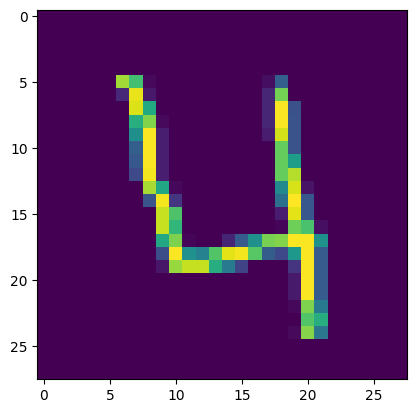

In [95]:
plt.imshow(df.iloc[3,1:].values.reshape(28,28))

In [96]:
X=df.drop(columns=['label'])
y=df['label']

In [97]:
from sklearn.model_selection import train_test_split

In [98]:
X_train,X_test,y_train,y_test = train_test_split(X,y,random_state=45,test_size=0.2)

In [99]:
X_train.shape

(33600, 784)

In [100]:
from sklearn.neighbors import KNeighborsClassifier

In [101]:
knn= KNeighborsClassifier()

In [102]:
knn.fit(X_train,y_train)

KNeighborsClassifier()

In [103]:
import time
start = time.time()
y_pred = knn.predict(X_test)
print(time.time()-start)

11.810783386230469


In [104]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.9671428571428572

In [105]:
# Using PCA

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [106]:
X_train_trf = scaler.fit_transform(X_train)
X_test_trf = scaler.transform(X_test)

In [107]:
from sklearn.decomposition import PCA

pca = PCA(n_components=150)

In [108]:
X_train_pca= pca.fit_transform(X_train_trf)
X_test_pca = pca.transform(X_test_trf)

In [109]:
X_train_pca.shape

(33600, 150)

In [110]:
knn = KNeighborsClassifier()

In [111]:
knn.fit(X_train_pca,y_train)

KNeighborsClassifier()

In [112]:
y_pred=knn.predict(X_test_pca)

In [113]:
accuracy_score(y_test,y_pred)

0.9501190476190476

In [ ]:
import time
start = time.time()
max_accuracy = 0
max_pca_component=0

for i in range(1,784):
    pca = PCA(n_components=i)
    X_train_pca= pca.fit_transform(X_train_trf)
    X_test_pca = pca.transform(X_test_trf)
    knn = KNeighborsClassifier()
    knn.fit(X_train_pca,y_train)
    y_pred=knn.predict(X_test_pca)
    # print(accuracy_score(y_test,y_pred))
    if(max_accuracy<accuracy_score(y_test,y_pred)):
        max_accuracy=accuracy_score(y_test,y_pred)
        max_pca_component=i


print("best accuracy",max_accuracy,"best pca components is",max_pca_component)
print(time.time()-start)
    